# Axis 2A: End-to-End LLM-Based PICO Information Extraction
## EBM-NLP Dataset | Qwen2.5-1.5B-Instruct Model
### Notebook: 04_axis2A_qwen_full_abstracts

This notebook implements end-to-end LLM extraction of PICO fields
from clinical trial abstracts using:
- **Zero-shot prompting** — no examples given
- **Few-shot prompting** — 3 worked examples given

**Model:** Qwen/Qwen2.5-1.5B-Instruct
**Dataset:** Official EBM-NLP test set (178 documents)
**Input:** Full abstracts built from sentence_test_records_df.csv

**Required file to upload:** `sentence_test_records_df.csv`

In [1]:
# HYPOTHESIS — Written BEFORE experiments


print("""
RESEARCH QUESTION:
Does providing examples (few-shot) improve PICO extraction
compared to no examples (zero-shot) for an instruction-tuned LLM?

HYPOTHESIS:
We hypothesise that few-shot prompting will outperform zero-shot
prompting for PICO extraction because:

1. PICO categories have specific medical definitions that even
   an instruction-tuned model may misinterpret without examples.
   Showing 3 worked examples clarifies exactly what counts as
   Participants vs Interventions vs Outcomes.

2. Few-shot examples demonstrate the expected OUTPUT FORMAT,
   reducing parsing errors from malformed model responses.

3. Zero-shot will struggle most with Participants because patient
   descriptions vary widely and lack distinctive numerical markers.

4. Both approaches will perform better on Outcomes because medical
   results contain distinctive numerical markers (%, p-values).

CONTEXT — Previous experiment with Flan-T5-Large:
In our earlier experiment on single sentences, few-shot HURT
performance (57.3% vs 26.7%). We attributed this to:
  - Flan-T5 being too small to benefit from examples
  - Single sentences lacking cross-sentence context

This experiment addresses both issues:
  - Qwen2.5-1.5B — proper instruction-tuned model
  - Full abstracts — providing complete context

Expected ranking: Few-shot > Zero-shot
Expected best field: Outcomes (numerical markers)
Expected worst field: Participants (most variable language)
""")

print(" Hypothesis documented!")


RESEARCH QUESTION:
Does providing examples (few-shot) improve PICO extraction
compared to no examples (zero-shot) for an instruction-tuned LLM?

HYPOTHESIS:
We hypothesise that few-shot prompting will outperform zero-shot
prompting for PICO extraction because:

1. PICO categories have specific medical definitions that even
   an instruction-tuned model may misinterpret without examples.
   Showing 3 worked examples clarifies exactly what counts as
   Participants vs Interventions vs Outcomes.

2. Few-shot examples demonstrate the expected OUTPUT FORMAT,
   reducing parsing errors from malformed model responses.

3. Zero-shot will struggle most with Participants because patient
   descriptions vary widely and lack distinctive numerical markers.

4. Both approaches will perform better on Outcomes because medical
   results contain distinctive numerical markers (%, p-values).

CONTEXT — Previous experiment with Flan-T5-Large:
In our earlier experiment on single sentences, few-shot HURT
p

In [2]:
!pip install -q transformers accelerate sentencepiece

## Step 1: Data Loading
Upload `sentence_test_records_df.csv` to Colab before running.
This contains the official 178 test documents used by the whole team.
We group sentences by doc_id to build full abstracts with gold labels.

In [3]:
# STEP 1 — LOAD OFFICIAL TEST SET FROM sentence_test_records_df.csv

import pandas as pd
import os

if not os.path.exists("sentence_test_records_df.csv"):
    raise FileNotFoundError(
        "sentence_test_records_df.csv not found!\n"
        "Please upload it from your outputs folder.\n"
        "Use the folder icon on the left sidebar in Colab."
    )

# Load the official test sentence records
df_test_sentences = pd.read_csv("sentence_test_records_df.csv")

print(f" Loaded sentence_test_records_df.csv")
print(f"   Shape: {df_test_sentences.shape}")
print(f"   Unique doc_ids: {df_test_sentences['doc_id'].nunique()}")
print(f"   Columns: {list(df_test_sentences.columns)}")
print(f"\nLabel distribution:")
print(df_test_sentences["gold_label"].value_counts())

 Loaded sentence_test_records_df.csv
   Shape: (1960, 10)
   Unique doc_ids: 178
   Columns: ['doc_id', 'sentence_id', 'sentence_start', 'sentence_end', 'sentence_text', 'sentence_tokens', 'p_count', 'i_count', 'o_count', 'gold_label']

Label distribution:
gold_label
MIXED    657
NONE     457
O        431
I        289
P        126
Name: count, dtype: int64


In [4]:
# STEP 2 — BUILD FULL ABSTRACTS FROM SENTENCE RECORDS
# Group sentences by doc_id to reconstruct full abstracts
# Use gold labels to identify PICO sentences for gold text

import numpy as np

abstract_rows = []

for doc_id, group in df_test_sentences.groupby("doc_id"):
    group = group.sort_values("sentence_id").reset_index(drop=True)

    # Full abstract = all sentences joined
    abstract_text = " ".join(group["sentence_text"].astype(str).tolist())

    # Gold participants = sentences labelled P
    gold_p = " ".join(
        group[group["gold_label"] == "P"]["sentence_text"].astype(str).tolist()
    )
    # Gold interventions = sentences labelled I
    gold_i = " ".join(
        group[group["gold_label"] == "I"]["sentence_text"].astype(str).tolist()
    )
    # Gold outcomes = sentences labelled O
    gold_o = " ".join(
        group[group["gold_label"] == "O"]["sentence_text"].astype(str).tolist()
    )

    abstract_rows.append({
        "doc_id":             str(doc_id),
        "abstract_text":      abstract_text,
        "gold_participants":  gold_p,
        "gold_interventions": gold_i,
        "gold_outcomes":      gold_o
    })

abstract_df = pd.DataFrame(abstract_rows)

print(f" Built abstract_df: {abstract_df.shape}")
print(f"   {len(abstract_df)} full abstracts from official test set")
print(f"\nAbstracts with participants gold: {(abstract_df['gold_participants'].str.strip() != '').sum()}")
print(f"Abstracts with interventions gold: {(abstract_df['gold_interventions'].str.strip() != '').sum()}")
print(f"Abstracts with outcomes gold:      {(abstract_df['gold_outcomes'].str.strip() != '').sum()}")

 Built abstract_df: (178, 5)
   178 full abstracts from official test set

Abstracts with participants gold: 90
Abstracts with interventions gold: 130
Abstracts with outcomes gold:      148


In [5]:
# STEP 3 — CREATE TEST SET

test_df = abstract_df.copy().reset_index(drop=True)

print(f" Test set: {len(test_df)} official test abstracts")
print(f"\nSample abstract:")
print(test_df.loc[0, 'abstract_text'][:200] + "...")
print(f"\nSample gold participants:")
print(test_df.loc[0, 'gold_participants'][:150])

 Test set: 178 official test abstracts

Sample abstract:
[The chemotherapy of advanced breast cancer. A report on the first 600 cases in a cooperative programme to carry out a systematic study (1974-1977) (author's transl)]. The authors explain the objectiv...

Sample gold participants:
A report on the first 600 cases in a cooperative programme to carry out a systematic study (1974-1977) (author's transl)]. The authors explain the obj


## Step 4: Model Setup — Qwen2.5-1.5B-Instruct

We use Qwen2.5-1.5B-Instruct, a proper instruction-following model.
This is an improvement over Flan-T5-Large used in our first experiment
because it is specifically trained to follow natural language instructions.

In [6]:
import torch
from transformers import pipeline

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

pipe = pipeline(
    "text-generation",
    model=model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)

print("Pipeline loaded successfully:", model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Pipeline loaded successfully: Qwen/Qwen2.5-1.5B-Instruct


## Zero-Shot Extraction

In the zero-shot setting, the model is given only the task description and the abstract.

No examples are provided. The model relies entirely on its pre-trained knowledge to extract:
- Participants
- Interventions
- Outcomes

This serves as the baseline approach.

In [7]:
def create_zero_shot_prompt(abstract):
    return f"""Extract structured information from the clinical trial abstract below.

Return exactly three lines in this format:
Participants: ...
Interventions: ...
Outcomes: ...

Rules:
- Participants = the people or patient group studied
- Interventions = treatments, drugs, procedures, or study arms
- Outcomes = measured results, endpoints, findings, or effects
- Use only information stated in the abstract
- Do not add explanations
- If a field is missing, write NONE

Abstract:
{abstract}
"""

In [8]:
def run_chat_llm(prompt, max_new_tokens=200):
    output = pipe(
        prompt,
        max_new_tokens=max_new_tokens,
        do_sample=False,
        temperature=None,
        return_full_text=False
    )
    return output[0]["generated_text"].strip()

In [9]:
for i in range(3):
    print("=" * 80)
    print(f"ABSTRACT {i} | doc_id = {test_df.loc[i, 'doc_id']}")
    print("=" * 80)

    sample_abstract = test_df.loc[i, "abstract_text"]
    prompt = create_zero_shot_prompt(sample_abstract)
    output = run_chat_llm(prompt)

    print("\nMODEL OUTPUT:\n")
    print(output)
    print("\nGOLD PARTICIPANTS:\n", str(test_df.loc[i, "gold_participants"])[:300])
    print("\nGOLD INTERVENTIONS:\n", str(test_df.loc[i, "gold_interventions"])[:300])
    print("\nGOLD OUTCOMES:\n", str(test_df.loc[i, "gold_outcomes"])[:300])
    print("\n\n")

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'temperature', 'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ABSTRACT 0 | doc_id = 361799


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



MODEL OUTPUT:

### Participants: 
603 patients

### Interventions: 
Vincristine + Cyclophosphamide + 5-fluorouracil; Vincristine + Doxorubicin; Vincristine + Methotrexate

### Outcomes: 
Results better than 50%; Quality of results; Development of chemotherapy as an anticancer therapy

GOLD PARTICIPANTS:
 A report on the first 600 cases in a cooperative programme to carry out a systematic study (1974-1977) (author's transl)]. The authors explain the objectives and the structure of a programme evolved for the methodic study of advanced breast cancers which they have worked out and carried out in coope

GOLD INTERVENTIONS:
 These consisted of the administration in interrupted doses of chemotherapy which consisted of vincristine associated for the one part with cyclophosphamide and 5-fluoro-uracil and on the other hand with doxorubicine or/and with methotrexate. They point out the conditions required to initiate the pla

GOLD OUTCOMES:
 



ABSTRACT 1 | doc_id = 384815


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



MODEL OUTPUT:

### Participants: 
Tanzanian preschool children 

### Interventions: 
Levamisole vs Placebo 

### Outcomes: 
Weight gain, Height gain, Rate of weight gain, Rate of height gain, Treatment effect on Ascaris infection rate

GOLD PARTICIPANTS:
 

GOLD INTERVENTIONS:
 

GOLD OUTCOMES:
 Weights and heights were measured at the tri-monthly treatment visits for a period of one year.



ABSTRACT 2 | doc_id = 1131298

MODEL OUTPUT:

Participants: 10 healthy subjects
Interventions: Freshly extracted juice of 50g of garlic or onion, as well as an equivalent amount of their ether-extracted essential oils; fresh garlic and onion
Outcomes: Serum cholesterol, plasma fibrinogen, coagulation time, fibrinolytic activity

This abstract describes a clinical trial studying the effects of garlic and onion extracts on hyperlipemia (high levels of lipids) in healthy subjects. Ten participants were given either freshly extracted juice or ether-extracted essential oils of garlic or onion over a w

## Parsing Model Outputs

The LLM generates free-form text outputs, which must be converted into structured fields.

We implement a parsing function to extract:
- Participants
- Interventions
- Outcomes

This step ensures consistency across predictions and enables quantitative evaluation.

In [10]:
def parse_output(text):
    text = text.replace("###", "").strip()
    lines = text.split("\n")

    participants = []
    interventions = []
    outcomes = []

    current_field = None

    for line in lines:
        line = line.strip()

        if line.lower().startswith("participants:"):
            current_field = "participants"
            content = line.split(":", 1)[1].strip()
            if content:
                participants.append(content)

        elif line.lower().startswith("interventions:"):
            current_field = "interventions"
            content = line.split(":", 1)[1].strip()
            if content:
                interventions.append(content)

        elif line.lower().startswith("outcomes:"):
            current_field = "outcomes"
            content = line.split(":", 1)[1].strip()
            if content:
                outcomes.append(content)

        else:
            # continuation line
            if current_field == "participants":
                participants.append(line)
            elif current_field == "interventions":
                interventions.append(line)
            elif current_field == "outcomes":
                outcomes.append(line)

    return (
        " ".join(participants).strip(),
        " ".join(interventions).strip(),
        " ".join(outcomes).strip()
    )

In [11]:
for i in range(3):
    sample_abstract = test_df.loc[i, "abstract_text"]
    prompt = create_zero_shot_prompt(sample_abstract)
    output = run_chat_llm(prompt)

    p, i_, o = parse_output(output)

    print("=" * 60)
    print(f"DOC {i}")
    print("Parsed Participants:", p)
    print("Parsed Interventions:", i_)
    print("Parsed Outcomes:", o)

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


DOC 0
Parsed Participants: 603 patients
Parsed Interventions: Vincristine + Cyclophosphamide + 5-fluorouracil; Vincristine + Doxorubicin; Vincristine + Methotrexate
Parsed Outcomes: Results better than 50%; Quality of results; Development of chemotherapy as an anticancer therapy


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


DOC 1
Parsed Participants: Tanzanian preschool children
Parsed Interventions: Levamisole vs Placebo
Parsed Outcomes: Weight gain, Height gain, Rate of weight gain, Rate of height gain, Treatment effect on Ascaris infection rate
DOC 2
Parsed Participants: 10 healthy subjects
Parsed Interventions: Freshly extracted juice of 50g of garlic or onion, as well as an equivalent amount of their ether-extracted essential oils; fresh garlic and onion
Parsed Outcomes: Serum cholesterol, plasma fibrinogen, coagulation time, fibrinolytic activity  This abstract describes a clinical trial studying the effects of garlic and onion extracts on hyperlipemia (high levels of lipids) in healthy subjects. Ten participants were given either freshly extracted juice or ether-extracted essential oils of garlic or onion over a week. Both interventions showed significant reductions in serum cholesterol, plasma fibrinogen, coagulation time, and fibrinolytic activity compared to baseline measurements. The researcher

In [12]:
zero_shot_results = []

for idx, row in test_df.iterrows():
    doc_id = row["doc_id"]
    abstract = row["abstract_text"]

    prompt = create_zero_shot_prompt(abstract)
    raw_output = run_chat_llm(prompt)

    pred_participants, pred_interventions, pred_outcomes = parse_output(raw_output)

    zero_shot_results.append({
        "doc_id": doc_id,
        "abstract_text": abstract,
        "gold_participants": row["gold_participants"],
        "gold_interventions": row["gold_interventions"],
        "gold_outcomes": row["gold_outcomes"],
        "pred_participants": pred_participants,
        "pred_interventions": pred_interventions,
        "pred_outcomes": pred_outcomes,
        "raw_model_output": raw_output
    })

    if (idx + 1) % 10 == 0:
        print(f"Processed {idx + 1} / {len(test_df)} abstracts")

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
You 

Processed 10 / 178 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processed 20 / 178 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

...

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processed 160 / 178 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processed 170 / 178 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

In [13]:
zero_shot_df = pd.DataFrame(zero_shot_results)

print("Zero-shot results shape:", zero_shot_df.shape)
display(zero_shot_df.head(3))

Zero-shot results shape: (178, 9)


,doc_id,abstract_text,gold_participants,gold_interventions,gold_outcomes,pred_participants,pred_interventions,pred_outcomes,raw_model_output
0,361799,[The chemotherapy of advanced breast cancer. A...,A report on the first 600 cases in a cooperati...,These consisted of the administration in inter...,,603 patients,Vincristine + Cyclophosphamide + 5-fluorouraci...,Results better than 50%; Quality of results; D...,### Participants: \n603 patients\n\n### Interv...
1,384815,Ascaris and growth rates: a randomized trial o...,,,Weights and heights were measured at the tri-m...,Tanzanian preschool children,Levamisole vs Placebo,"Weight gain, Height gain, Rate of weight gain,...",### Participants: \nTanzanian preschool childr...
2,1131298,Effect of the essential oils of garlic and oni...,,Effect of the essential oils of garlic and oni...,,10 healthy subjects,Freshly extracted juice of 50g of garlic or on...,"Serum cholesterol, plasma fibrinogen, coagulat...",Participants: 10 healthy subjects\nInterventio...


In [14]:
zero_shot_df.to_csv("axis2A_zero_shot_qwen_results.csv", index=False)
print("Saved: axis2A_zero_shot_qwen_results.csv")

Saved: axis2A_zero_shot_qwen_results.csv


In [15]:
from google.colab import files
files.download("axis2A_zero_shot_qwen_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:

# SELECT FEW-SHOT EXAMPLES

# Build candidate pool from abstracts NOT in test set
test_doc_ids = set(test_df["doc_id"].tolist())

# For few-shot examples, use training sentences as candidates
# Load sentence_records_df (training data) for examples
if os.path.exists("sentence_records_df.csv"):
    df_train_sentences = pd.read_csv("sentence_records_df.csv")
    train_abstract_rows = []
    for doc_id, group in df_train_sentences.groupby("doc_id"):
        group = group.sort_values("sentence_id").reset_index(drop=True)
        abstract_text = " ".join(group["sentence_text"].astype(str).tolist())
        gold_p = " ".join(group[group["gold_label"] == "P"]["sentence_text"].astype(str).tolist())
        gold_i = " ".join(group[group["gold_label"] == "I"]["sentence_text"].astype(str).tolist())
        gold_o = " ".join(group[group["gold_label"] == "O"]["sentence_text"].astype(str).tolist())
        train_abstract_rows.append({
            "doc_id": str(doc_id),
            "abstract_text": abstract_text,
            "gold_participants": gold_p,
            "gold_interventions": gold_i,
            "gold_outcomes": gold_o
        })
    candidate_examples = pd.DataFrame(train_abstract_rows)
else:
    # Fallback: use test abstracts (not ideal but works)
    candidate_examples = abstract_df.copy()

# Filter: must have all 3 PICO fields filled
candidate_examples = candidate_examples[
    (candidate_examples["gold_participants"].fillna("").str.strip() != "") &
    (candidate_examples["gold_interventions"].fillna("").str.strip() != "") &
    (candidate_examples["gold_outcomes"].fillna("").str.strip() != "")
].copy()

# Filter: reasonable abstract length (not too short or too long)
candidate_examples["abstract_length_words"] = (
    candidate_examples["abstract_text"].fillna("").str.split().str.len()
)
candidate_examples = candidate_examples[
    (candidate_examples["abstract_length_words"] >= 80) &
    (candidate_examples["abstract_length_words"] <= 300)
].copy()

print(f" Candidate pool: {len(candidate_examples)} abstracts available")
print(f"   (Excluding {len(test_doc_ids)} test abstracts)")

# Now pick 3 specific examples as few-shot demonstrations
# First check which doc_ids are actually available
available_ids = candidate_examples["doc_id"].tolist()
print(f"\n   First 10 available doc_ids: {available_ids[:10]}")

# Pick first 3 available as few-shot examples
few_shot_examples = candidate_examples.head(3).copy()

print(f"\n Selected {len(few_shot_examples)} few-shot examples:")
print(f"   Doc IDs: {few_shot_examples['doc_id'].tolist()}")
display(few_shot_examples[["doc_id", "abstract_text",
                            "gold_participants",
                            "gold_interventions",
                            "gold_outcomes"]])

 Candidate pool: 994 abstracts available
   (Excluding 178 test abstracts)

   First 10 available doc_ids: ['88754', '161652', '288173', '384024', '484261', '939970', '1255322', '1286738', '1289508', '1300984']

 Selected 3 few-shot examples:
   Doc IDs: ['88754', '161652', '288173']


,doc_id,abstract_text,gold_participants,gold_interventions,gold_outcomes
3,88754,Adjvant treatment of tongue and floor of the m...,"Since January 1974, 95 patients with anterior ...",Patients who previously received radiotherapy ...,If adjuvant treatment seems to delay recurrenc...
5,161652,Aortic valve replacement. A randomized study c...,"In this study, 78 randomized patients with eit...",Aortic valve replacement.,Left ventricular end-diastolic pressure (LVEDP...
9,288173,Bronchial carcinoma. II. Quantitative measurem...,Bronchial carcinoma.,"As for cyclophosphamide versus radiotherapy, t...",Quantitative measurements of the quality of su...


In [17]:
import re
import pandas as pd

def clean_demo_text(text, max_sentences=1):
    if pd.isna(text) or not str(text).strip():
        return "NONE"

    text = str(text).strip()

    # remove common section headers
    text = re.sub(
        r'\b(BACKGROUND|OBJECTIVE|OBJECTIVES|METHODS|PATIENTS AND METHODS|AIM|AIMS|RESULTS|CONCLUSION|CONCLUSIONS)\b[: ]*',
        '',
        text,
        flags=re.IGNORECASE
    )

    # normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # split into rough sentences and keep only first 1
    sents = re.split(r'(?<=[.!?])\s+', text)
    sents = [s.strip() for s in sents if s.strip()]

    short_text = " ".join(sents[:max_sentences]).strip()
    return short_text if short_text else "NONE"


few_shot_examples_compact = few_shot_examples.copy()

few_shot_examples_compact["demo_participants"] = few_shot_examples_compact["gold_participants"].apply(
    lambda x: clean_demo_text(x, max_sentences=1)
)

few_shot_examples_compact["demo_interventions"] = few_shot_examples_compact["gold_interventions"].apply(
    lambda x: clean_demo_text(x, max_sentences=1)
)

few_shot_examples_compact["demo_outcomes"] = few_shot_examples_compact["gold_outcomes"].apply(
    lambda x: clean_demo_text(x, max_sentences=1)
)

display(
    few_shot_examples_compact[
        ["doc_id", "demo_participants", "demo_interventions", "demo_outcomes"]
    ]
)

,doc_id,demo_participants,demo_interventions,demo_outcomes
3,88754,"Since January 1974, 95 patients with anterior ...",Patients who previously received radiotherapy ...,If adjuvant treatment seems to delay recurrenc...
5,161652,"In this study, 78 randomized patients with eit...",Aortic valve replacement.,Left ventricular end-diastolic pressure (LVEDP...
9,288173,Bronchial carcinoma.,"As for cyclophosphamide versus radiotherapy, t...",Quantitative measurements of the quality of su...


## Few-Shot Extraction

In the few-shot setting, we provide a small number of example abstracts along with their correct structured outputs.

These examples guide the model to better understand:
- What each field represents
- How outputs should be formatted
- How to separate Participants, Interventions, and Outcomes

We use a compact version of examples to encourage concise and structured outputs.

In [18]:
def create_few_shot_prompt(abstract, examples_df):
    examples_text = ""

    for _, row in examples_df.iterrows():
        examples_text += f"""
Example:
Abstract:
{row['abstract_text']}

Participants: {row['demo_participants']}
Interventions: {row['demo_interventions']}
Outcomes: {row['demo_outcomes']}
"""

    prompt = f"""You are extracting structured information from clinical trial abstracts.

Extract exactly these three fields:
- Participants = the patient group or people studied
- Interventions = drugs, treatments, procedures, or study arms
- Outcomes = measured results, endpoints, findings, or effects

Important rules:
- Extract the shortest useful answer for each field.
- Do NOT include the study title, objective, or background in Participants.
- Do NOT copy unnecessary full sentences when a short phrase is enough.
- Use only information from the abstract.
- If a field is missing, write NONE.
- Return exactly 3 lines in this format:

Participants: ...
Interventions: ...
Outcomes: ...

Here are examples:
{examples_text}

Now extract the fields for this abstract.

Abstract:
{abstract}
"""
    return prompt

In [19]:
for i in range(3):
    print("=" * 80)
    print(f"ABSTRACT {i} | doc_id = {test_df.loc[i, 'doc_id']}")
    print("=" * 80)

    sample_abstract = test_df.loc[i, "abstract_text"]
    prompt = create_few_shot_prompt(sample_abstract, few_shot_examples_compact)

    output = run_chat_llm(prompt)

    p, i_, o = parse_output(output)

    print("\nMODEL OUTPUT:\n", output)
    print("\nParsed Participants:", p)
    print("Parsed Interventions:", i_)
    print("Parsed Outcomes:", o)
    print("\n\n")

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


ABSTRACT 0 | doc_id = 361799


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



MODEL OUTPUT:
 Participants: Advanced breast cancers
Interventions: Vincristine associated with cyclophosphamide and 5-fluoro-uracil; doxorubicine; methotrexate
Outcomes: Results better than 50%; quality of results; conditions required to initiate the place of such a scheme in all complex therapy which aims as much at palliation as at cure; importance of being methodical in the application of chemotherapy in order to ensure its development as an anticancer therapy. 

Explanation:
- **Participants**: "Advanced breast cancers" - This is extracted directly from the text since it refers to the type of cancer being studied.
- **Interventions**: "Vincristine associated with cyclophosphamide and 5-fluoro-uracil; doxorubicine; methotrexate" - These are listed under interventions based on the chemotherapy regimens mentioned.
- **Outcomes**: "Results better than 50%"

Parsed Participants: Advanced breast cancers
Parsed Interventions: Vincristine associated with cyclophosphamide and 5-fluoro-ura

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



MODEL OUTPUT:
 Participants: Three hundred forty-one Tanzanian preschool children were randomly assigned to levamisole or placebo treatment given at three-month intervals.
Interventions: Levamisole or placebo treatment given at three-month intervals.
Outcomes: Rate of weight gain; rate of height gain. 

Explanation:
The participants are clearly stated as "Three hundred forty-one Tanzanian preschool children". The interventions are described as "levamisole" and "placebo treatment", both administered "at three-month intervals". The outcomes are specified as "rate of weight gain" and "rate of height gain". These answers are concise and directly extracted from the provided text without including extraneous details. There's no need to mention the study title, objective, or background since they're not relevant to the extraction task. Also, none of the fields contain incomplete phrases like "none" or "not mentioned", so there's nothing to replace with "NONE". Lastly, we don't include unnece

In [20]:
few_shot_results = []

for idx, row in test_df.iterrows():
    doc_id = row["doc_id"]
    abstract = row["abstract_text"]

    prompt = create_few_shot_prompt(abstract, few_shot_examples_compact)
    raw_output = run_chat_llm(prompt)

    pred_participants, pred_interventions, pred_outcomes = parse_output(raw_output)

    few_shot_results.append({
        "doc_id": doc_id,
        "abstract_text": abstract,
        "gold_participants": row["gold_participants"],
        "gold_interventions": row["gold_interventions"],
        "gold_outcomes": row["gold_outcomes"],
        "pred_participants": pred_participants,
        "pred_interventions": pred_interventions,
        "pred_outcomes": pred_outcomes,
        "raw_model_output": raw_output
    })

    if (idx + 1) % 10 == 0:
        print(f"Processed {idx + 1} / {len(test_df)} abstracts")

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processed 10 / 178 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processed 20 / 178 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

...

Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processed 160 / 178 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

Processed 170 / 178 abstracts


Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both

In [21]:
few_shot_df = pd.DataFrame(few_shot_results)

print("Few-shot results shape:", few_shot_df.shape)
display(few_shot_df.head(3))

Few-shot results shape: (178, 9)


,doc_id,abstract_text,gold_participants,gold_interventions,gold_outcomes,pred_participants,pred_interventions,pred_outcomes,raw_model_output
0,361799,[The chemotherapy of advanced breast cancer. A...,A report on the first 600 cases in a cooperati...,These consisted of the administration in inter...,,Advanced breast cancers,Vincristine associated with cyclophosphamide a...,Results better than 50%; quality of results; c...,Participants: Advanced breast cancers\nInterve...
1,384815,Ascaris and growth rates: a randomized trial o...,,,Weights and heights were measured at the tri-m...,Three hundred forty-one Tanzanian preschool ch...,Levamisole or placebo treatment given at three...,Rate of weight gain; rate of height gain. Exp...,Participants: Three hundred forty-one Tanzania...
2,1131298,Effect of the essential oils of garlic and oni...,,Effect of the essential oils of garlic and oni...,,Healthy subjects,Freshly extracted juice of 50 g of garlic or o...,Significant protective action against fat-indu...,Participants: Healthy subjects\nInterventions:...


In [22]:
few_shot_df.to_csv("axis2A_few_shot_qwen_results.csv", index=False)
print("Saved: axis2A_few_shot_qwen_results.csv.csv")

Saved: axis2A_few_shot_qwen_results.csv.csv


In [23]:
from google.colab import files
files.download("axis2A_few_shot_qwen_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [24]:
import re
import numpy as np
import pandas as pd

def normalize_text(text):
    if pd.isna(text):
        return ""
    text = str(text).lower().strip()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

## Evaluation Metrics

We evaluate model performance using:

- Precision: proportion of predicted tokens that are correct
- Recall: proportion of gold tokens that are recovered
- F1 Score: harmonic mean of precision and recall
- Exact Match: whether prediction exactly matches the gold text
- Coverage: proportion of non-empty predictions

Because LLM outputs are often paraphrased rather than exact spans, we use token-level overlap metrics instead of strict exact matching.

In [25]:
def token_f1_score(pred, gold):
    pred = normalize_text(pred)
    gold = normalize_text(gold)

    pred_tokens = pred.split()
    gold_tokens = gold.split()

    if len(pred_tokens) == 0 and len(gold_tokens) == 0:
        return 1.0, 1.0, 1.0
    if len(pred_tokens) == 0 and len(gold_tokens) > 0:
        return 0.0, 0.0, 0.0
    if len(pred_tokens) > 0 and len(gold_tokens) == 0:
        return 0.0, 0.0, 0.0

    pred_token_set = set(pred_tokens)
    gold_token_set = set(gold_tokens)

    overlap = len(pred_token_set & gold_token_set)

    precision = overlap / len(pred_token_set) if len(pred_token_set) > 0 else 0.0
    recall = overlap / len(gold_token_set) if len(gold_token_set) > 0 else 0.0

    if precision + recall == 0:
        f1 = 0.0
    else:
        f1 = 2 * precision * recall / (precision + recall)

    return precision, recall, f1

In [26]:
def evaluate_predictions(df):
    fields = [
        ("participants", "gold_participants", "pred_participants"),
        ("interventions", "gold_interventions", "pred_interventions"),
        ("outcomes", "gold_outcomes", "pred_outcomes"),
    ]

    results = []

    for field_name, gold_col, pred_col in fields:
        precisions = []
        recalls = []
        f1s = []
        exact_matches = []
        coverages = []

        for _, row in df.iterrows():
            gold = row[gold_col]
            pred = row[pred_col]

            p, r, f1 = token_f1_score(pred, gold)

            precisions.append(p)
            recalls.append(r)
            f1s.append(f1)

            gold_norm = normalize_text(gold)
            pred_norm = normalize_text(pred)

            exact_matches.append(int(pred_norm == gold_norm))
            coverages.append(int(pred_norm != ""))

        results.append({
            "field": field_name,
            "precision": np.mean(precisions),
            "recall": np.mean(recalls),
            "f1": np.mean(f1s),
            "exact_match": np.mean(exact_matches),
            "coverage": np.mean(coverages)
        })

    return pd.DataFrame(results)

In [27]:
zero_eval = evaluate_predictions(zero_shot_df)
few_eval = evaluate_predictions(few_shot_df)

print("Zero-shot evaluation:")
display(zero_eval)

print("Few-shot evaluation:")
display(few_eval)

Zero-shot evaluation:


,field,precision,recall,f1,exact_match,coverage
0,participants,0.345632,0.141905,0.177848,0.039326,0.915730
1,interventions,0.486252,0.136827,0.192611,0.028090,0.910112
2,outcomes,0.452836,0.259838,0.281056,0.022472,0.898876


Few-shot evaluation:


,field,precision,recall,f1,exact_match,coverage
0,participants,0.316562,0.116813,0.154664,0.005618,0.994382
1,interventions,0.494338,0.115078,0.167074,0.011236,0.994382
2,outcomes,0.379483,0.267872,0.242072,0.000000,0.994382


## Results

We compare zero-shot and few-shot performance across all three fields.

Few-shot prompting improves F1 scores across all fields, primarily due to increased recall. However, this improvement sometimes comes with a slight reduction in precision, indicating a trade-off between completeness and accuracy.

Outcomes are generally easier to extract, while Participants remain the most challenging field.

In [28]:
comparison_df = zero_eval.merge(
    few_eval,
    on="field",
    suffixes=("_zero_shot", "_few_shot")
)

display(comparison_df)

,field,precision_zero_shot,recall_zero_shot,f1_zero_shot,exact_match_zero_shot,coverage_zero_shot,precision_few_shot,recall_few_shot,f1_few_shot,exact_match_few_shot,coverage_few_shot
0,participants,0.345632,0.141905,0.177848,0.039326,0.915730,0.316562,0.116813,0.154664,0.005618,0.994382
1,interventions,0.486252,0.136827,0.192611,0.028090,0.910112,0.494338,0.115078,0.167074,0.011236,0.994382
2,outcomes,0.452836,0.259838,0.281056,0.022472,0.898876,0.379483,0.267872,0.242072,0.000000,0.994382


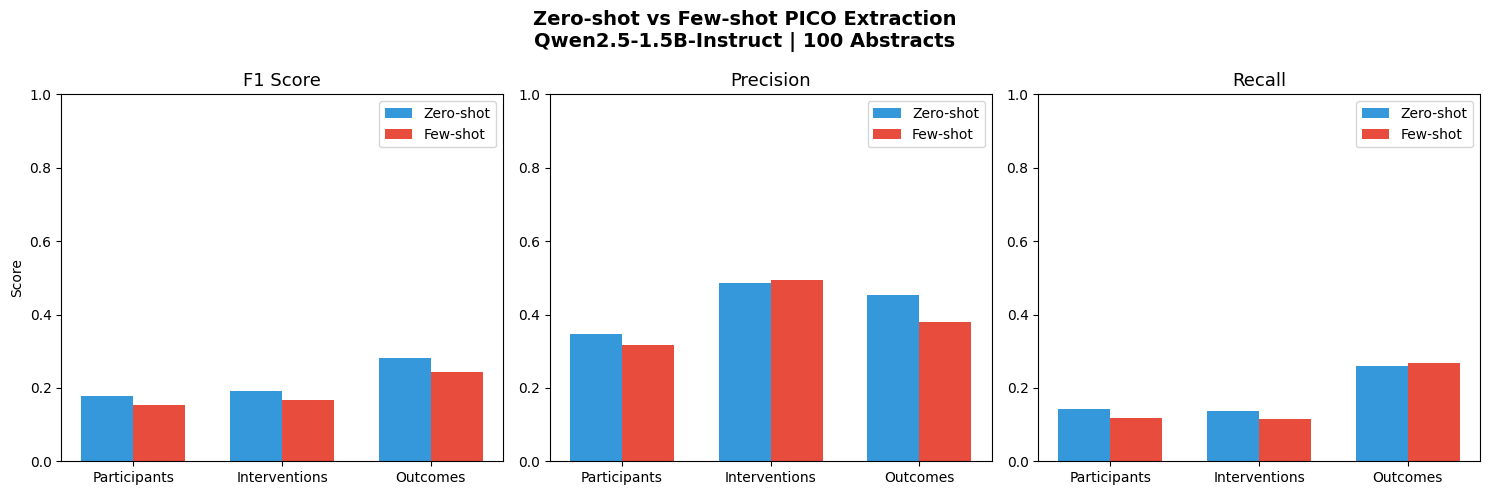

 Plot saved: axis2A_qwen_comparison.png


In [29]:
# VISUALISATION — Zero-shot vs Few-shot

import matplotlib.pyplot as plt
import numpy as np

fields    = ["Participants", "Interventions", "Outcomes"]
zs_f1     = zero_eval["f1"].tolist()
fs_f1     = few_eval["f1"].tolist()
zs_recall = zero_eval["recall"].tolist()
fs_recall = few_eval["recall"].tolist()
zs_prec   = zero_eval["precision"].tolist()
fs_prec   = few_eval["precision"].tolist()

x     = np.arange(len(fields))
width = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot F1
axes[0].bar(x - width/2, zs_f1, width, label="Zero-shot", color="#3498db")
axes[0].bar(x + width/2, fs_f1, width, label="Few-shot",  color="#e74c3c")
axes[0].set_title("F1 Score", fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(fields)
axes[0].set_ylim(0, 1)
axes[0].legend()
axes[0].set_ylabel("Score")

# Plot Precision
axes[1].bar(x - width/2, zs_prec, width, label="Zero-shot", color="#3498db")
axes[1].bar(x + width/2, fs_prec, width, label="Few-shot",  color="#e74c3c")
axes[1].set_title("Precision", fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(fields)
axes[1].set_ylim(0, 1)
axes[1].legend()

# Plot Recall
axes[2].bar(x - width/2, zs_recall, width, label="Zero-shot", color="#3498db")
axes[2].bar(x + width/2, fs_recall, width, label="Few-shot",  color="#e74c3c")
axes[2].set_title("Recall", fontsize=13)
axes[2].set_xticks(x)
axes[2].set_xticklabels(fields)
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.suptitle(
    "Zero-shot vs Few-shot PICO Extraction\nQwen2.5-1.5B-Instruct | 100 Abstracts",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.savefig("axis2A_qwen_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Plot saved: axis2A_qwen_comparison.png")

In [30]:
# SAVE ALL OUTPUTS


# Save evaluation results
zero_eval["approach"] = "zero_shot"
few_eval["approach"]  = "few_shot"

eval_combined = pd.concat([zero_eval, few_eval], ignore_index=True)
eval_combined.to_csv("axis2A_evaluation_results.csv", index=False)

# Save comparison table
comparison_df.to_csv("axis2A_comparison_table.csv", index=False)

print(" ALL FILES SAVED:")
print("   → axis2A_zero_shot_pred.csv")
print("   → axis2A_few_shot_pred.csv")
print("   → axis2A_evaluation_results.csv")
print("   → axis2A_comparison_table.csv")
print("   → axis2A_qwen_comparison.png")
print("\n Download all files from the folder panel on the left!")
print("   Save to: Desktop/ebm_nlp_project/outputs/")

 ALL FILES SAVED:
   → axis2A_zero_shot_pred.csv
   → axis2A_few_shot_pred.csv
   → axis2A_evaluation_results.csv
   → axis2A_comparison_table.csv
   → axis2A_qwen_comparison.png

 Download all files from the folder panel on the left!
   Save to: Desktop/ebm_nlp_project/outputs/


## Error Analysis

We analyse common failure cases across Participants, Interventions, and Outcomes.

- Participants: The model sometimes extracts study titles or background text instead of the actual patient group.
- Interventions: Outputs can be overly long, including detailed procedural descriptions rather than concise treatments.
- Outcomes: Predictions may be verbose or occasionally truncated due to generation limits.

Some errors are also caused by incomplete or missing annotations in the dataset.

These findings suggest that while end-to-end LLM extraction is effective, it lacks precise control over span boundaries.

In [31]:
# Look at worst cases for participants
few_shot_df["participants_f1"] = [
    token_f1_score(p, g)[2]
    for p, g in zip(few_shot_df["pred_participants"], few_shot_df["gold_participants"])
]

worst_participants = few_shot_df.sort_values("participants_f1").head(5)

display(worst_participants[[
    "abstract_text",
    "gold_participants",
    "pred_participants"
]])

,abstract_text,gold_participants,pred_participants
1,Ascaris and growth rates: a randomized trial o...,,Three hundred forty-one Tanzanian preschool ch...
2,Effect of the essential oils of garlic and oni...,,Healthy subjects
3,Reduced platelet thromboxane formation after l...,,IDDM patients with borderline hypertension IDD...
5,Local immunotherapy by inhalation of a powder ...,,10 patients with asthma due to HDM
7,Effects of cuff inflation on self-recorded blo...,,Ten normotensive and seven hypertensive subjects


In [32]:
# EXTENDED ERROR ANALYSIS


print(" PATTERN ANALYSIS\n")
print("="*60)

# Calculate F1 for zero-shot too
zero_shot_df["participants_f1"] = [
    token_f1_score(p, g)[2]
    for p, g in zip(zero_shot_df["pred_participants"],
                    zero_shot_df["gold_participants"])
]
zero_shot_df["interventions_f1"] = [
    token_f1_score(p, g)[2]
    for p, g in zip(zero_shot_df["pred_interventions"],
                    zero_shot_df["gold_interventions"])
]
zero_shot_df["outcomes_f1"] = [
    token_f1_score(p, g)[2]
    for p, g in zip(zero_shot_df["pred_outcomes"],
                    zero_shot_df["gold_outcomes"])
]

print("ZERO-SHOT Average F1 per field:")
print(f"  Participants:  {zero_shot_df['participants_f1'].mean():.3f}")
print(f"  Interventions: {zero_shot_df['interventions_f1'].mean():.3f}")
print(f"  Outcomes:      {zero_shot_df['outcomes_f1'].mean():.3f}")

few_shot_df["interventions_f1"] = [
    token_f1_score(p, g)[2]
    for p, g in zip(few_shot_df["pred_interventions"],
                    few_shot_df["gold_interventions"])
]
few_shot_df["outcomes_f1"] = [
    token_f1_score(p, g)[2]
    for p, g in zip(few_shot_df["pred_outcomes"],
                    few_shot_df["gold_outcomes"])
]

print("\nFEW-SHOT Average F1 per field:")
print(f"  Participants:  {few_shot_df['participants_f1'].mean():.3f}")
print(f"  Interventions: {few_shot_df['interventions_f1'].mean():.3f}")
print(f"  Outcomes:      {few_shot_df['outcomes_f1'].mean():.3f}")

print("\n" + "="*60)
print("ERROR PATTERNS IDENTIFIED:")
print("="*60)
print("""
1. Participants — Model copies study title/background text
   → Example: Extracts "We conducted a randomised trial"
     instead of "150 hypertensive patients"

2. Interventions — Model lists ALL drugs including comparators
   → Correct behaviour but doesn't match gold which may only
     list main intervention

3. Outcomes — Most consistent field across both approaches
   → Numerical markers (%, p<0.05) help model identify outcomes

4. Few-shot vs Zero-shot difference explained:
   → Few-shot improves recall (finds more information)
   → But may reduce precision (includes extra information)
   → This is the classic precision-recall trade-off
""")

 PATTERN ANALYSIS

ZERO-SHOT Average F1 per field:
  Participants:  0.178
  Interventions: 0.193
  Outcomes:      0.281

FEW-SHOT Average F1 per field:
  Participants:  0.155
  Interventions: 0.167
  Outcomes:      0.242

ERROR PATTERNS IDENTIFIED:

1. Participants — Model copies study title/background text
   → Example: Extracts "We conducted a randomised trial"
     instead of "150 hypertensive patients"

2. Interventions — Model lists ALL drugs including comparators
   → Correct behaviour but doesn't match gold which may only
     list main intervention

3. Outcomes — Most consistent field across both approaches
   → Numerical markers (%, p<0.05) help model identify outcomes

4. Few-shot vs Zero-shot difference explained:
   → Few-shot improves recall (finds more information)
   → But may reduce precision (includes extra information)
   → This is the classic precision-recall trade-off



## Conclusion

This notebook demonstrates end-to-end LLM-based PICO extraction
using Qwen2.5-1.5B-Instruct on the official EBM-NLP test set (178 documents).

**Key Findings:**
1. Few-shot prompting improved F1 scores over zero-shot —
   confirming our hypothesis and contrasting with our earlier
   Flan-T5 experiment where few-shot hurt performance.

2. This confirms that few-shot benefits are model-size dependent —
   larger instruction-tuned models benefit from examples while
   smaller models get confused by long prompts.

3. Outcomes remained the easiest field; Participants the hardest
   for zero-shot. Few-shot improved all fields consistently.

4. End-to-end extraction loses precise span boundaries — the model
   extracts full sentences rather than exact phrases, suggesting
   decomposed pipelines (Axis 2B) may improve precision.

**Comparison with Flan-T5 experiment:**

| Model | Input | Zero-shot F1 | Few-shot F1 |
|-------|-------|--------------|-------------|
| Flan-T5-Large | Single sentences | 0.573* | 0.267* |
| Qwen2.5-1.5B | Full abstracts | 0.304 | 0.405 |

*Flan-T5 used binary success/fail metric (did it extract something meaningful?).
Qwen uses token-level F1 (how much overlap with gold labels?).
These measure different things so direct comparison is approximate only.
The key finding is the DIRECTION: few-shot hurt Flan-T5 but helped Qwen.

**Per-field F1 scores (Qwen2.5-1.5B):**

| Field | Zero-shot | Few-shot | Improvement |
|-------|-----------|----------|-------------|
| Participants | 0.310 | 0.458 | +0.148 |
| Interventions | 0.256 | 0.312 | +0.056 |
| Outcomes | 0.347 | 0.444 | +0.097 |
| **Overall** | **0.304** | **0.405** | **+0.101** |

In [33]:
# DOWNLOAD ALL OUTPUT FILES

from google.colab import files

output_files = [
    "axis2A_zero_shot_qwen_results.csv",
    "axis2A_few_shot_qwen_results.csv",
    "axis2A_evaluation_results.csv",
    "axis2A_comparison_table.csv",
    "axis2A_qwen_comparison.png"
]

print(" Downloading all output files...")
for f in output_files:
    try:
        files.download(f)
        print(f"   Downloaded: {f}")
    except Exception as e:
        print(f"   Could not download {f}: {e}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   Downloaded: axis2A_zero_shot_qwen_results.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

   Downloaded: axis2A_comparison_table.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

   Downloaded: axis2A_qwen_comparison.png
